In [1]:
import os
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
load_dotenv()
llm=ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002483699D160>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002483699DBE0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
tool = TavilySearch(max_results=2)


In [5]:
def addition(a:int,b:int)->int:
    """_addition_

    Args:
        a (int): _first integer_
        b (int): _secondinteger_

    Returns:
        int: _result_
    """
    return a+b

In [6]:
tools = [tool , addition]
llm_with_tools = llm.bind_tools(tools)


def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

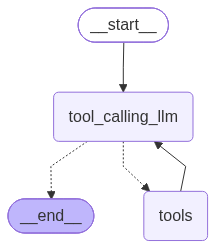

In [7]:
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm" , tool_calling_llm)
graph_builder.add_node("tools" , ToolNode(tools))

graph_builder.add_edge(START , "tool_calling_llm")
graph_builder.add_conditional_edges("tool_calling_llm", tools_condition)
## instead of going to the END tool node go back to the tool calling llm
graph_builder.add_edge("tools" , "tool_calling_llm")

graph_builder.compile()

In [8]:
graph = graph_builder.compile()
response = graph.invoke({"messages":"Hi! Give me latest AI News and the add 2 and 7"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi! Give me latest AI News and the add 2 and 7
================================== Ai Message ==================================
Tool Calls:
  tavily_search (47x4nhpnv)
 Call ID: 47x4nhpnv
  Args:
    query: latest AI news
    time_range: day
    topic: news
  addition (5vbzrv5pt)
 Call ID: 5vbzrv5pt
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newswire.com/news/netsertive-announces-the-latest-ai-native-version-of-mlx-introduces-version-3-0", "title": "Netsertive Announces the Latest AI-Native Version of MLX, Introduces Version 3.0 of its Multi-Location Experience Platform", "content": "\"The latest version of the platform seamlessly leverages best-of-breed models and serverless AI functions such as Amazon'

#### Adding Memory to Agentic Graph

In [9]:
response = graph.invoke({"messages":"Hello my name is Zainab"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Zainab
================================== Ai Message ==================================

Hello Zainab, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [10]:
response = graph.invoke({"messages":"Hello what is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello what is my name
================================== Ai Message ==================================

I don't have any information about your name. If you want to provide it, I'm happy to chat with you about it.


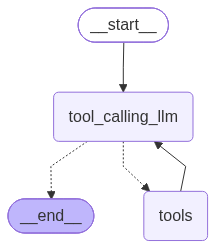

In [11]:
# MemorySaver is going to save memory with respect to every node 
from langgraph.checkpoint.memory import MemorySaver
#create memory object
memory = MemorySaver()
#build graph

graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm" , tool_calling_llm)
graph_builder.add_node("tools" , ToolNode(tools))

graph_builder.add_edge(START , "tool_calling_llm")
graph_builder.add_conditional_edges("tool_calling_llm", tools_condition)
## instead of going to the END tool node go back to the tool calling llm
graph_builder.add_edge("tools" , "tool_calling_llm")

#add the memory object we created here to a parameter checkpointer while compiling 
graph_builder.compile(checkpointer = memory)

In [12]:
graph = graph_builder.compile(checkpointer = memory)

In [13]:
# for using this memory we need to create thread id because it will be reated to un specific session

# create variable config
# inside config reate a key named configurable
# inside configurable create thread. This thread should be given a unique id
config={"configurable":{"thread_id":"1"}}

In [14]:
# provide the thread id during the invoke
response = graph.invoke({"messages":"hi my name is Zainab"} , config = config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

hi my name is Zainab
================================== Ai Message ==================================

Nice to meet you, Zainab. How can I assist you today?


In [15]:
# ask again
response = graph.invoke({"messages":"hi what is my name"} , config = config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

hi my name is Zainab
================================== Ai Message ==================================

Nice to meet you, Zainab. How can I assist you today?
================================ Human Message =================================

hi what is my name
================================== Ai Message ==================================

Zainab


#### Streaming in Langgraph

In [16]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()


In [17]:
def superbot(state:State):
    return{"messages":[llm.invoke(state['messages'])]}

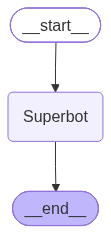

In [18]:
graph = StateGraph(State)

graph.add_node("Superbot" , superbot)

graph.add_edge(START, "Superbot")
graph.add_edge("Superbot" , END)

graph.compile(checkpointer=memory)



In [19]:
graph_builder = graph.compile(checkpointer=memory)

In [20]:
#now create thread

config = {"configurable": {"thread_id":"1"}}



In [21]:
graph_builder.invoke({"messages":"Hi! My name is Zainab. You can call me Zaini. I love coding"},config)

{'messages': [HumanMessage(content='Hi! My name is Zainab. You can call me Zaini. I love coding', additional_kwargs={}, response_metadata={}, id='0886ca7e-3bd8-4054-a92c-07a8e7b01782'),
  AIMessage(content="Nice to meet you, Zaini! It's great to hear that you're passionate about coding. What programming languages or areas of coding are you currently interested in or working on?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 55, 'total_tokens': 93, 'completion_time': 0.065187001, 'completion_tokens_details': None, 'prompt_time': 0.003205921, 'prompt_tokens_details': None, 'queue_time': 0.005430114, 'total_time': 0.068392922}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fcb6d-6c35-77e3-b750-70af261c6993-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 55, 'output_to

###### in streaming we use two methods
###### .stream() and astream()
###### additional parameters used in streaming mode fro graph state are
###### values: it streams the full state of the graph after each node is called
###### updates: it streams updates to the state of the graph afer each node is called

In [22]:
## create a thread

config = {"configurable":{"thread_id":"3"}}
 ## Gives you only what changed at each step just the specific node's output, not the whole state.
for chunk in graph_builder.stream({"messages":"Hi, my name is Zainab ans i love pizza"}, config , stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Zainab. It's great to hear that you love pizza. Pizza is one of the most popular foods worldwide, and for good reason - it's delicious, customizable, and can be enjoyed in countless ways. What's your favorite type of pizza? Do you like classic margherita, meat-lovers, vegetarian, or something a bit more adventurous?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 47, 'total_tokens': 125, 'completion_time': 0.138240116, 'completion_tokens_details': None, 'prompt_time': 0.002805045, 'prompt_tokens_details': None, 'queue_time': 0.005482327, 'total_time': 0.141045161}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fcb6d-7b7c-7352-81e2-3a17742db4ba-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_

In [23]:
# values gives entire current state after each node finishes running
for chunk in graph_builder.stream({"messages":"Hi, my name is Zainab ans i love pizza"}, config , stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Zainab ans i love pizza', additional_kwargs={}, response_metadata={}, id='12dc1635-11f0-4fa3-9dc3-1321d8efef5a'), AIMessage(content="Nice to meet you, Zainab. It's great to hear that you love pizza. Pizza is one of the most popular foods worldwide, and for good reason - it's delicious, customizable, and can be enjoyed in countless ways. What's your favorite type of pizza? Do you like classic margherita, meat-lovers, vegetarian, or something a bit more adventurous?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 47, 'total_tokens': 125, 'completion_time': 0.138240116, 'completion_tokens_details': None, 'prompt_time': 0.002805045, 'prompt_tokens_details': None, 'queue_time': 0.005482327, 'total_time': 0.141045161}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'

In [24]:
config = {"configurable":{"thread_id":"5"}}

async for event in graph_builder.astream_events({"messages":["Hi my name is Zainab and i Like reading books"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi my name is Zainab and i Like reading books']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019fcb6d-8e70-7cb0-b54a-3fc4a5a4b37e', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is Zainab and i Like reading books', additional_kwargs={}, response_metadata={}, id='fe49d446-5e82-401c-b27f-1f2cf814e5be')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019fcb6d-8e75-7e81-8b54-07be00d225bc', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:8fad9b11-1333-8ac3-7803-661e8aa9bfcd'}, 'parent_ids': ['019fcb6d-8e70-7cb0-b54a-3fc4a5a4b37e']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [